# SPHEREx Self-calibration Dev

In [1]:
import glob
import os
import h5py
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 # User can set this outside the class if needed

from astropy.io import fits
from astropy.io.votable import parse_single_table
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u

import sys 
import gc 

import importlib
# sys.path.insert(0, '/home/thomasli/spherex/selfcal')
from SelfCal import EuclidUtility
from SelfCal import WCSHelper
from SelfCal import MakeMap
from SelfCal import MapHelper
importlib.reload(MapHelper)

import os
import h5py
from tqdm import tqdm
from multiprocessing import Pool 
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u
from astropy.table import Table

from reproject import reproject_interp
from reproject import reproject_exact
from reproject import reproject_adaptive

from scipy.sparse import coo_matrix
from scipy.sparse.linalg import lsqr
import sys 
import gc 
from functools import partial

from SelfCal.MapHelper import bit_to_bool, make_weight, find_outliers, map_pixels,compute_chunk_contrib, det_to_grid
from SelfCal.WCSHelper import load_from_fits, save_to_fits, find_optimal_frame


In [2]:
from SelfCal.SPHERExUtility import make_fiducial_chunk_mask, load_calibration, make_fiducial_chunk_map, extract_spherex_channel_edges, make_spherex_chunk_map, interp_2d_vertical

In [3]:
from SelfCal.MakeMap import *
from SelfCal.MapHelper import *

In [4]:
detector = 1

det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')

In [5]:
chunk_map = make_fiducial_chunk_map(detector, det_BC, num_subchannels=10, num_channels=17)
chunk_valid_mask = make_fiducial_chunk_mask([4],  num_subchannels=10, num_channels=17)
det_valid_mask = chunk_valid_mask[chunk_map]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 172/172 [00:09<00:00, 17.31it/s]


In [ ]:
channel_edges = [0.87, 1.0]
chunk_map = make_spherex_chunk_map(detector, det_BC, fine_edges=channel_edges)
chunk_valid_mask = channel_edges==1

In [6]:
from SelfCal.MakeMap import _prep_subframe, load_reproj_file

In [7]:
reproj_list = glob.glob('/data3/thomasli/selfcal/outputs/nep_det1_3p1arcsec/reprojected/*.h5')
reproj_sample = load_reproj_file(reproj_list[-10], fields=['sub_data', 'sub_header', 'det_header', 
                                                         'ref_coords', 'file_path', 'grid_bitmask', 'grid_mapping', 'sub_foot'])

In [8]:
from sys import getsizeof

In [30]:
for key in reproj_sample:
    dtype = reproj_sample[key].dtype if hasattr(reproj_sample[key], 'dtype') else type(reproj_sample[key])
    size = getsizeof(reproj_sample[key])
    print(f'{key}: {dtype}, {size} bytes')

sub_data: float32, 159012228 bytes
sub_header: <class 'bytes'>, 2913 bytes
det_header: <class 'bytes'>, 20193 bytes
ref_coords: int32, 128 bytes
file_path: <class 'bytes'>, 157 bytes
grid_bitmask: int32, 636048528 bytes
grid_mapping: int16, 636048544 bytes
sub_foot: int16, 79506178 bytes
_is_missing_: <class 'bool'>, 28 bytes


In [14]:
file = reproj_list[0]
exp_idx = 0
det_idx = 0
chunk_map = chunk_map
det_valid_mask = det_valid_mask
apply_weight = False
apply_mask = True
chunk_offset = np.arange(len(chunk_valid_mask))
ignore_list = []
valid_threshold = 0.99
for_lsqr = True
interp_func = interp_2d_vertical

In [9]:
fields=['sub_data', 'ref_coords', 'grid_mapping']
if apply_mask:
    fields.append('grid_bitmask')
result = load_reproj_file(file, fields=fields)

data = result['sub_data']
coords = result['ref_coords']
grid_mapping = result['grid_mapping']

In [10]:
oversample_factor = 1
if grid_mapping is not None and data.shape[-1] > 0:
    oversample_factor = int(grid_mapping.shape[-1] / data.shape[-1])

sub_mask = np.ones_like(data, dtype=bool)
if 'grid_bitmask' in result:
    bitmask = result['grid_bitmask']
    sub_mask &= grid_bitmask_to_sub_mask(
        bitmask, oversample_factor, ignore_list=ignore_list, valid_threshold=valid_threshold
    )

In [ ]:
det_maps_to_process = []
map_keys = []
if chunk_offset is not None:
    offset_map = compute_offset_map(chunk_offset, chunk_map, interp_func=interp_func)
    det_maps_to_process.append(offset_map)
    map_keys.append('offset')
if det_valid_mask is not None:
    det_maps_to_process.append(det_valid_mask)
    map_keys.append('valid_mask')
if det_maps_to_process:
    stacked_det_maps = np.stack(det_maps_to_process, axis=0)
    stacked_grid_maps = det_to_grid(grid_mapping, stacked_det_maps)
    stacked_sub_maps = [bin2d_cv(grid_map, oversample_factor) for grid_map in stacked_grid_maps]
    # stacked_sub_maps = bin2d_cv(stacked_grid_maps, bin_factor=oversample_factor)
    if 'offset' in map_keys:
        data -= stacked_sub_maps[map_keys.index('offset')]
    if 'valid_mask' in map_keys:
        sub_mask &= (stacked_sub_maps[map_keys.index('valid_mask')] > 0.5)

In [21]:
stacked_sub_maps = [bin2d_cv(grid_map, oversample_factor) for grid_map in stacked_grid_maps]


In [94]:
stacked_det_maps = np.stack(det_maps_to_process, axis=0)
stacked_grid_maps = [det_to_grid(grid_mapping, det_data=det_map) for det_map in stacked_det_maps]
stacked_sub_maps = [bin2d_cv(grid_map, oversample_factor) for grid_map in stacked_grid_maps]
# stacked_sub_maps = bin2d_cv(stacked_grid_maps, bin_factor=oversample_factor)
if 'offset' in map_keys:
    data -= stacked_sub_maps[map_keys.index('offset')]
if 'valid_mask' in map_keys:
    sub_mask &= (stacked_sub_maps[map_keys.index('valid_mask')] > 0.5)

In [36]:
data[~sub_mask] = np.nan

weight = make_weight(data) if apply_weight else np.ones_like(data, dtype=np.float32)

chunk_contrib = None
if for_lsqr:
    chunk_contrib = compute_chunk_contrib(
        grid_mapping=grid_mapping,
        chunk_map=chunk_map,
        oversample_factor=oversample_factor
    )

In [266]:
from mpsplines import MeanPreservingInterpolation as MPI

def interp_1d(arr, method='mp', edge='extend'):
    idx = np.arange(len(arr))
    start = np.where(arr[:-1] != arr[1:])[0]+1
    mean_idx = (start[:-1] + (start[1:] - 1))/2
    mean_val = arr[start[:-1]]
    if method == 'mp':
        # https://github.com/jararias/mpsplines
        mpi = MPI(yi=mean_val, xi=mean_idx, min_val=0.00)
        smooth_arr = mpi(idx, )
    elif method == 'linear':
        smooth_arr = np.interp(idx, mean_idx, mean_val)
        
    return smooth_arr

def parse_bin(arr):
    idx = np.arange(len(arr))
    start = np.where(arr[:-1] != arr[1:])[0]+1
    edge = start - 1/2
    mean_idx = (start[:-1] + (start[1:] - 1))/2
    mean_val = arr[start[:-1]]
    return mean_idx, mean_val, edge

def interp_2d_vertical(arr, method='mp'):
    return np.apply_along_axis(interp_1d, axis=0, arr=arr, method=method)

In [108]:
def compute_offset_map(chunk_offset, chunk_map, interp_func=None):
    offset_map = chunk_offset[chunk_map]
    if interp_func is not None:
        assert callable(interp_func), "interp_func must be a callable function"
        # Apply interpolation function if provided
        offset_map = interp_func(offset_map)
    return offset_map


In [109]:
offset_map = chunk_offset[chunk_map]

In [113]:
for i in range(2040):
    interp_1d(offset_map[:,i])

In [106]:
o = compute_offset_map(chunk_offset, chunk_map, interp_func=interp_2d_vertical)

In [114]:
o_org = chunk_offset[chunk_map]

In [363]:
o_org

array([[171, 171, 171, ..., 171, 171, 171],
       [171, 171, 171, ..., 171, 171, 171],
       [171, 171, 171, ..., 171, 171, 171],
       ...,
       [  1,   1,   1, ...,   1,   1,   1],
       [  0,   0,   0, ...,   1,   1,   1],
       [  0,   0,   0, ...,   0,   0,   0]], shape=(2040, 2040))

In [352]:
x = np.arange(1000)
org = np.exp(-(x-510)**2/100) + np.exp(-(x-530)**2/100) + (x/1000)**2 + \
    np.exp(-(x-400)**2/100) + np.exp(-(x-410)**2/100) + np.exp(-(x-440)**2/100) + \
     + np.exp(-(x-580)**2/10) + np.exp(-(x-630)**2/30) + np.exp(-(x-680)**2/60)
binned = np.zeros_like(org)
bin_size = int(2040/17/20)
for i in range(0, len(org), bin_size):
    binned[i:i+bin_size] = np.mean(org[i:i+bin_size])
mpi = interp_1d(binned)
lin = interp_1d(binned, method='linear')

mean_idx, mean_val, _ = parse_bin(binned)
# use pchip
from scipy.interpolate import PchipInterpolator
pchip_interp = PchipInterpolator(mean_idx, mean_val)
scipy = pchip_interp(x)


In [361]:
%%time
mpi = interp_1d(binned)

CPU times: user 42.3 ms, sys: 1.74 ms, total: 44 ms
Wall time: 41.5 ms


In [362]:
%%time
mean_idx, mean_val, edge = parse_bin(binned)
mps_custom = mean_preserving_spline(edge, mean_val, method='cubic')
mps_interp = mps_custom(x)

CPU times: user 1.08 ms, sys: 47 μs, total: 1.12 ms
Wall time: 1.01 ms


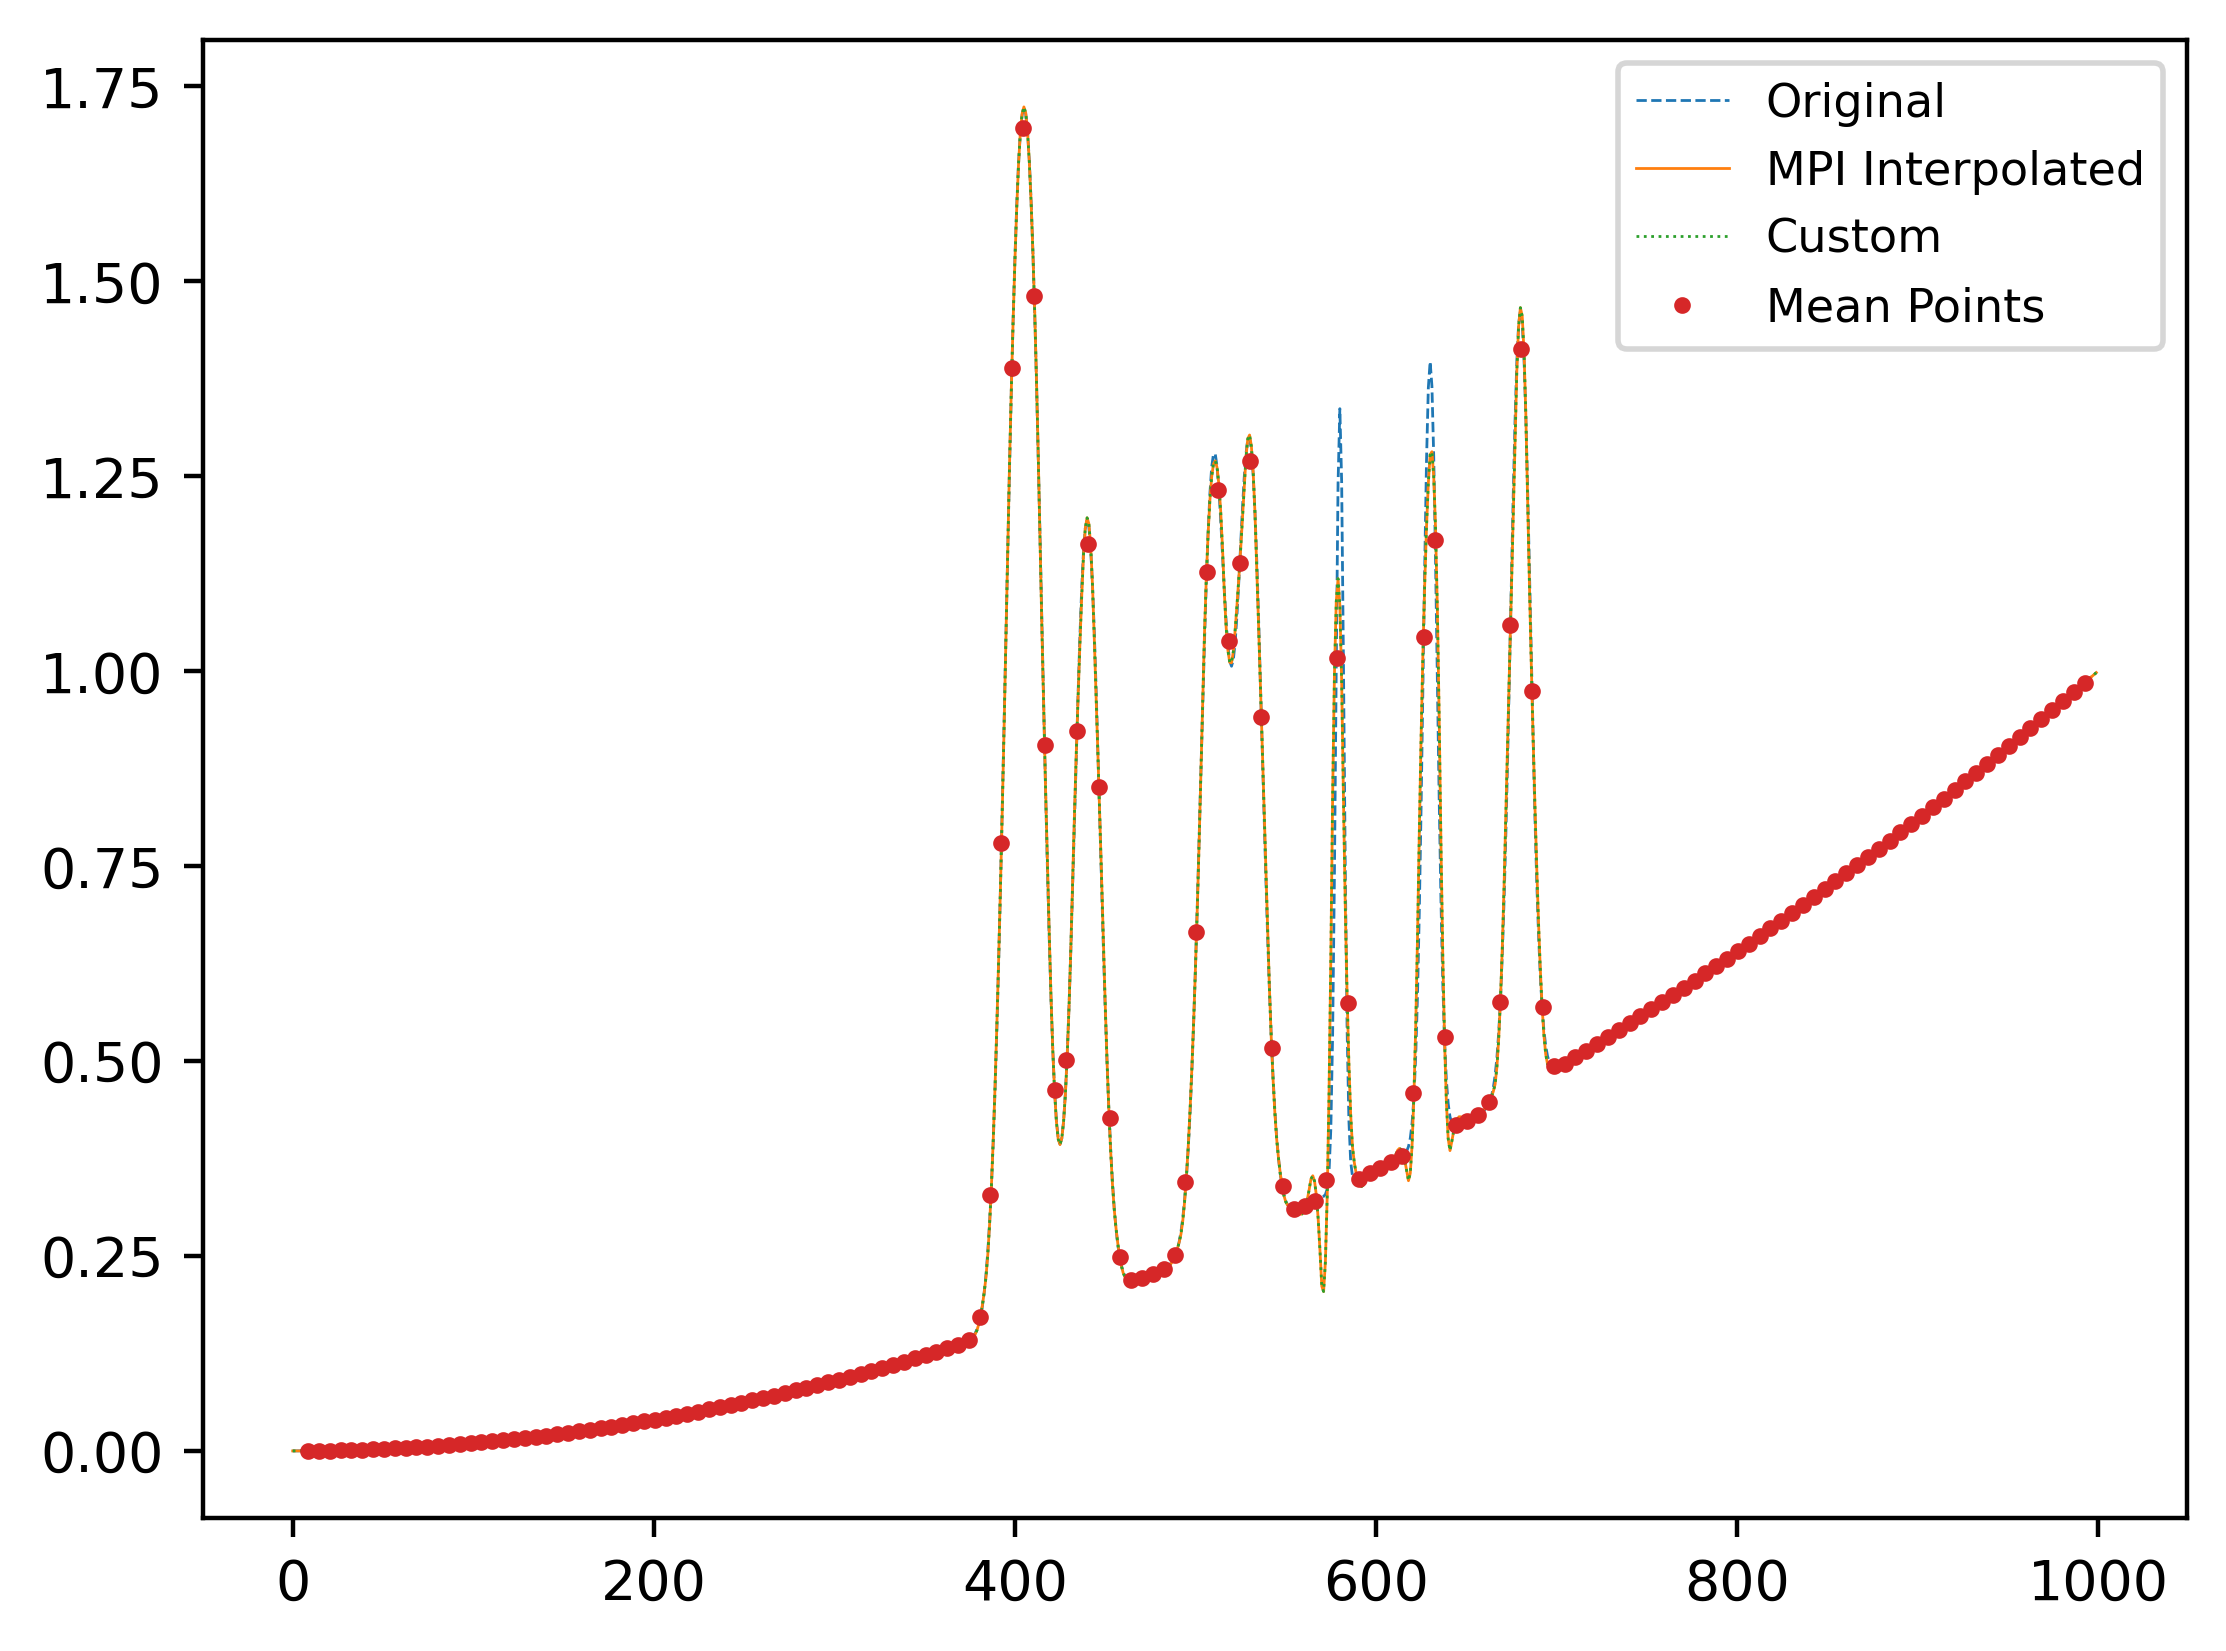

In [354]:
plt.plot(x, org, label='Original', ls='--', linewidth=0.5)
# plt.plot(x, binned, label='Binned', linewidth=0.5)
plt.plot(x, mpi, label='MPI Interpolated', linewidth=0.5)
# plt.plot(x, lin, label='Linear Interpolated', linewidth=0.5)
plt.plot(x, mps_interp, label='Custom', linewidth=0.5, ls=':')
plt.plot(mean_idx, mean_val, 'o', label='Mean Points', markersize=2)

# smaller legend
plt.legend(fontsize='small')
# plt.xlim(950, 1000)

In [364]:
cal_path = '/data1/thomasli/selfcal/outputs/nep_det1_6p2arcsec/calibration/cal_det1_ch15-17_10band_newO.h5'
chunk_valid_mask = make_fiducial_chunk_mask([15, 16, 17], num_subchannels=10)
chunk_valid_mask[141:146] = 0
chunk_valid_mask[166:] = 0

with h5py.File(cal_path, 'r') as f:
    sub_O = f['O'][:][exp_idx][chunk_valid_mask==1]

In [365]:
sub_O

array([0.20325344, 0.20334618, 0.2078201 , 0.21684374, 0.25071888,
       0.32612352, 0.42841372, 0.54453657, 0.6431316 , 0.68072446,
       0.69052558, 0.69177551, 0.67402169, 0.67901679, 0.68031024,
       0.64451263, 0.53209121, 0.37518292, 0.28705378, 0.24712496])